In [1]:
import numpy as np

# Format: (impact [0-3], possibility (0-1], label)
test_cases = [
    # Mundane baseline
    (0, 0.90, "Common & No Impact (e.g., Right-hand mouse)"),
    # Rare quirks (Impact 0, Low P) - THE KEY FOCUS
    (0, 0.10, "Uncommon Quirk (e.g., Left-hand mouse)"),
    (0, 0.01, "Rare Quirk (e.g., Hyprland + Minimal config)"),
    (0, 0.001, "Extreme Eccentricity (e.g., Rare niche habit)"),
    # Impactful decisions
    (1, 0.10, "Uncommon Workflow (e.g., LazyVim)"),
    (1, 0.01, "Rare Technical Choice (e.g., NixOS over Windows)"),
    (2, 0.05, "Unconventional Career Move"),
    (3, 0.30, "High Impact Common Choice (e.g., University degree)"),
    (3, 0.01, "High Impact Rare Strategy (e.g., Moving abroad solo)"),
]


def score_exponential(impact: int, p: float) -> float:
    """Current: e^(impact) * (-log2 P)"""
    return np.exp(impact) * (-np.log2(max(p, 1e-6)))


def score_shifted_linear(impact: int, p: float) -> float:
    """Shifted Linear: (1 + impact) * (-log2 P)"""
    return (1 + impact) * (-np.log2(max(p, 1e-6)))


def score_additive(impact: int, p: float) -> float:
    """Additive: impact + (-log2 P)"""
    return impact + (-np.log2(max(p, 1e-6)))


print(
    f"{'Imp':<3} | {'Prob':<6} | {'Exponential':<11} | {'Shifted Lin':<11} | {'Additive':<10} | {'Description'}"
)
print("-" * 80)

for impact, p, desc in test_cases:
    s_exp = score_exponential(impact, p)
    s_lin = score_shifted_linear(impact, p)
    s_add = score_additive(impact, p)
    print(
        f"{impact:<3} | {p:<6.3f} | {s_exp:<11.2f} | {s_lin:<11.2f} | {s_add:<10.2f} | {desc}"
    )

Imp | Prob   | Exponential | Shifted Lin | Additive   | Description
--------------------------------------------------------------------------------
0   | 0.900  | 0.15        | 0.15        | 0.15       | Common & No Impact (e.g., Right-hand mouse)
0   | 0.100  | 3.32        | 3.32        | 3.32       | Uncommon Quirk (e.g., Left-hand mouse)
0   | 0.010  | 6.64        | 6.64        | 6.64       | Rare Quirk (e.g., Hyprland + Minimal config)
0   | 0.001  | 9.97        | 9.97        | 9.97       | Extreme Eccentricity (e.g., Rare niche habit)
1   | 0.100  | 9.03        | 6.64        | 4.32       | Uncommon Workflow (e.g., LazyVim)
1   | 0.010  | 18.06       | 13.29       | 7.64       | Rare Technical Choice (e.g., NixOS over Windows)
2   | 0.050  | 31.93       | 12.97       | 6.32       | Unconventional Career Move
3   | 0.300  | 34.89       | 6.95        | 4.74       | High Impact Common Choice (e.g., University degree)
3   | 0.010  | 133.45      | 26.58       | 9.64       | High Impact

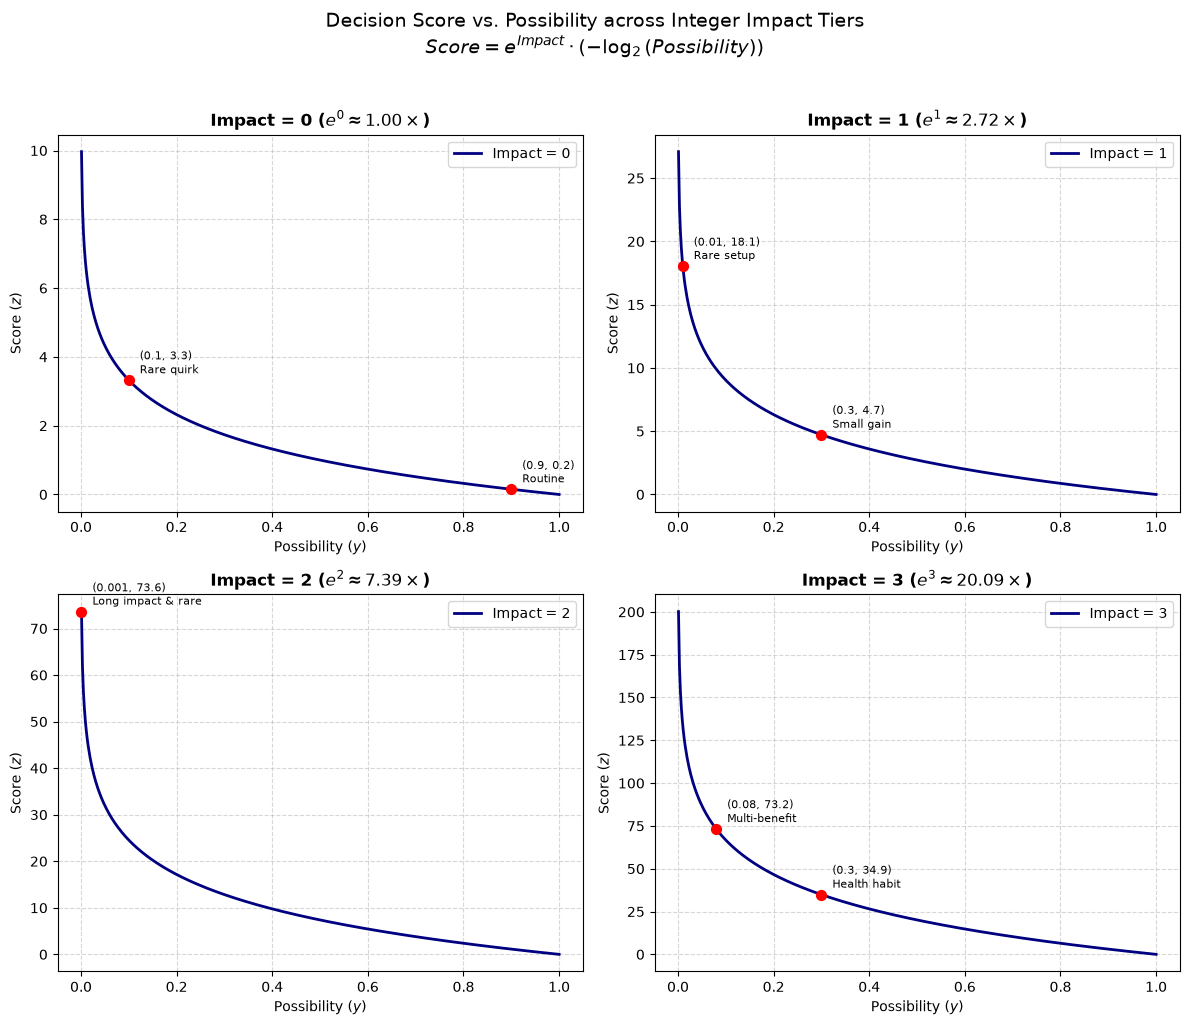

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Test cases: (impact, possibility, label)
test_sets = [
    (0, 0.9, "Routine"),
    (0, 0.1, "Rare quirk"),
    (1, 0.3, "Small gain"),
    (1, 0.01, "Rare setup"),
    (2, 0.001, "Long impact & rare"),
    (3, 0.08, "Multi-benefit"),
    (3, 0.3, "Health habit"),
]

# Continuous possibility range (avoid 0 to prevent log2 division error)
y = np.linspace(0.001, 1.0, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for impact_val in range(4):
    ax = axes[impact_val]

    # Calculate curve: Score = exp(impact) * (-log2(possibility))
    multiplier = np.exp(impact_val)
    score = multiplier * (-np.log2(y))

    # Plot curve
    ax.plot(
        y, score, color="navy", linewidth=2, label=f"Impact = {impact_val}"
    )

    # Overlay test points for this specific impact tier
    pts = [pt for pt in test_sets if pt[0] == impact_val]
    for pt_impact, pt_y, label in pts:
        pt_score = np.exp(pt_impact) * (-np.log2(pt_y))
        ax.scatter(pt_y, pt_score, color="red", s=50, zorder=5)
        ax.annotate(
            f" ({pt_y}, {pt_score:.1f})\n {label}",
            (pt_y, pt_score),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

    # Panel styling
    ax.set_title(
        f"Impact = {impact_val} ($e^{{{impact_val}}} \\approx {multiplier:.2f}\\times$)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Possibility ($y$)", fontsize=10)
    ax.set_ylabel("Score ($z$)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right")

plt.suptitle(
    "Decision Score vs. Possibility across Integer Impact Tiers\n$Score = e^{Impact} \\cdot (-\\log_2(Possibility))$",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()